# Investigation: Plasma -> Epithelial, Plasma rule (Multi-Stage Evaluation)

This notebook investigates the association rule **Plasma -> Epithelial, Plasma** across different disease stages (Control, Mild, Severe). It calculates per-FOV metrics to directly compare standard FP-Growth (binary) vs Weighted FP-Growth (distance-decay) pass rates.

**What it represents:** IgA plasma cell barrier adjacent to epithelium (both duodenum and colon).
**Expected pattern:** Decreases from Control to Mild to Severe across tissues (loss of barrier).

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../../'))
from utils.rules import build_cell_item_token, passes_rule_support_policy, _extract_base_lineage

# --- Notebook config (no constants.py) ---
USE_FUNCTIONAL_MARKERS = True
CELLTYPE_MARKER_THRESHOLDS = {
    'Epithelial': {'Ki67': 2.5, 'HLADRDPDQ': 1.75},
    'CD8T': {'Ki67': 2.5, 'CD103': 2.0, 'CD69': 2.0, 'GZMB': 2.5},
    'CD4T': {'Ki67': 1.0, 'CD103': 1.0, 'CD69': 2.0, 'GZMB': 0.5},
    'Neutrophil': {'CD103': 2.75},
    'Neutrophil_CD15': {'CD103': 2.75}
}
CONFIG = {
    'RADIUS': 25.0,
    'BANDWIDTH': 15.0,
    'MIN_SUPPORT': 0.01,
    'MIN_ABS_SUPPORT': 5,
    'MIN_CONFIDENCE': 0.3,
    'MIN_LIFT': 1.2,
    'MIN_CELLS_PER_PATCH': 2,
    'HIGH_CONFIDENCE_THRESHOLD': 0.9,
    'HIGH_CONF_MIN_SUPPORT': 0.005,
}

RADIUS = CONFIG['RADIUS']
BANDWIDTH = CONFIG.get('BANDWIDTH', RADIUS)
MIN_SUPPORT = CONFIG['MIN_SUPPORT']
MIN_ABS_SUPPORT = CONFIG.get('MIN_ABS_SUPPORT', 5)
MIN_CONFIDENCE = CONFIG['MIN_CONFIDENCE']
MIN_LIFT = CONFIG['MIN_LIFT']
STAGE_COLUMN = "Pathological score"
STAGE_FOV_METRICS = []
SCORE_COLUMN = 'Pathological score'  # change to 'Clinical score' if needed

ANTECEDENT_BASE = 'Plasma'
ANTECEDENT_REQUIRED_MARKERS = ()
CONSEQUENT_BASE = 'Epithelial'
CONSEQUENT_REQUIRED_MARKERS = ()


## Step 1: Data Loading & Functional Subtypes

Load the cell and metadata tables, identify disease stages, and append the `functional_subtypes` array to every cell.

In [2]:
def _add_functional_subtypes(df):
    if not USE_FUNCTIONAL_MARKERS:
        df["functional_subtypes"] = [[] for _ in range(len(df))]
        return df
    functional_subtypes_list = [[] for _ in range(len(df))]
    idx_to_pos = {idx: i for i, idx in enumerate(df.index)}
    for base_type, markers in CELLTYPE_MARKER_THRESHOLDS.items():
        type_mask = df["cell type"] == base_type
        for marker, threshold in markers.items():
            if marker in df.columns:
                mask = type_mask & (df[marker] > threshold)
                subtype_label = f"{base_type}_{marker}+"
                matching_indices = df.index[mask]
                for idx in matching_indices:
                    functional_subtypes_list[idx_to_pos[idx]].append(subtype_label)
    df["functional_subtypes"] = functional_subtypes_list
    return df

cell_table_path = '../../data/MIBIGutCsv/cell_table.csv'
fov_meta_path = '../../data/MIBIGutCsv/fovs_metadata.csv'
biopsy_meta_path = '../../data/MIBIGutCsv/biopsy_metadata.csv'

df_cells = pd.read_csv(cell_table_path)
df_fovs = pd.read_csv(fov_meta_path)
df_biopsy = pd.read_csv(biopsy_meta_path)

# Merge FOV with Biopsy to get score columns and Localization
df_fovs = pd.merge(
    df_fovs,
    df_biopsy[['Biopsy_ID', 'Pathological score', 'Clinical score', 'Localization']],
    left_on='Patient',
    right_on='Biopsy_ID',
    how='left'
)

# --- Standardized Organ Enrichment (from investigation_01_colon.ipynb) ---
def get_organ(row):
    if pd.notna(row.get("Localization")): return row["Localization"]
    cohort = str(row.get("Cohort", ""))
    if "Colon" in cohort: return "Colon"
    if "Duodenum" in cohort: return "Duodenum"
    return "Unknown"

df_fovs["Organ"] = df_fovs.apply(get_organ, axis=1)
# -------------------------------------------------------------------------

# Define FOV lists for each cohort, explicitly split by Stage and Organ
control_cohorts = ['Duodenum_Cohort_Control_1', 'Duodenum_Cohort_Control_2', 'Colon_Cohort_Control']

# Colon
colon_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_mild_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Mild') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_severe_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Severe') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()

# Duodenum
duodenum_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_mild_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Mild') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_severe_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Severe') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()

# Normalize Coordinates
fov_to_size = df_fovs.set_index('FOV')['Size [um]'].to_dict()
def normalize_coords(row):
    size = fov_to_size.get(row['fov'], 800)
    res = 1024 if size == 400 else 2048
    return row['centroid_x'] * (size / res), row['centroid_y'] * (size / res)

df_cells[['x_um', 'y_um']] = df_cells.apply(lambda row: pd.Series(normalize_coords(row)), axis=1)

# Add Functional Subtypes
df_cells = _add_functional_subtypes(df_cells)

print(f"Total Cells: {len(df_cells)}")
print(f"Colon Control FOVs: {len(colon_control_fovs)}")
print(f"Colon Mild FOVs: {len(colon_mild_fovs)}")
print(f"Colon Severe FOVs: {len(colon_severe_fovs)}")
print(f"Duodenum Control FOVs: {len(duodenum_control_fovs)}")
print(f"Duodenum Mild FOVs: {len(duodenum_mild_fovs)}")
print(f"Duodenum Severe FOVs: {len(duodenum_severe_fovs)}")
print(f"Stage column used: {SCORE_COLUMN}")



Total Cells: 713372
Colon Control FOVs: 25
Colon Mild FOVs: 40
Colon Severe FOVs: 32
Duodenum Control FOVs: 52
Duodenum Mild FOVs: 103
Duodenum Severe FOVs: 36
Stage column used: Pathological score


## Step 2: Evaluation Framework

Define a reusable function that iterates over a given list of FOVs, computes both binary and weighted metrics *per FOV*, and verifies how many FOVs pass the algorithm thresholds. Finally, it visualizes the FOV with the highest target cell density.

In [3]:
def evaluate_cohort(cohort_name, fov_list, df_cells_all):
    print(f"==============================================")
    print(f"Evaluating Cohort: {cohort_name}")
    print(f"==============================================\n")

    binary_pass_count = 0
    weighted_pass_count = 0
    valid_fovs = 0

    global_binary_transactions = []
    global_weighted_transactions = []
    passing_binary_transactions = []
    passing_weighted_transactions = []

    max_target_count = -1
    max_target_fov = None
    fov_metrics = []
    organ = None
    stage = cohort_name
    if " - " in cohort_name:
        organ, stage = [part.strip() for part in cohort_name.split(" - ", 1)]

    def _parse_token(token, suffix):
        token = str(token)
        tail = f"_{suffix}"
        if not token.endswith(tail):
            return None, set()
        core = token[:-len(tail)]
        base = _extract_base_lineage(core)
        markers = {part for part in core.split('_') if part.endswith('+')}
        return base, markers

    def _matches_rule_item(token, base, suffix, required_markers=()):
        token_base, token_markers = _parse_token(token, suffix)
        if token_base != base:
            return False
        return set(required_markers).issubset(token_markers)

    def _has_item(binary_trans, base, suffix, required_markers=()):
        return any(_matches_rule_item(item, base, suffix, required_markers) for item in binary_trans)

    def _weight_for_item(weighted_trans, base, suffix, required_markers=()):
        return min(
            sum(float(v) for k, v in weighted_trans.items() if _matches_rule_item(k, base, suffix, required_markers)),
            1.0,
        )

    def _conviction(confidence, support_con):
        if confidence >= 1:
            return float("inf")
        denom = 1 - confidence
        if denom <= 0:
            return float("inf")
        return (1 - support_con) / denom

    def _rule_item_label(base, required_markers):
        if not required_markers:
            return base
        return f"{base}_{'_'.join(required_markers)}"

    for fov in fov_list:
        fov_data = df_cells_all[df_cells_all['fov'] == fov]
        if fov_data.empty:
            continue
        valid_fovs += 1

        coords = fov_data[['x_um', 'y_um']].values
        types = fov_data['cell type'].values
        subtypes = fov_data['functional_subtypes'].values

        target_count = sum(
            1
            for t, st in zip(types, subtypes)
            if _matches_rule_item(
                build_cell_item_token(t, st, suffix='CENTER'),
                ANTECEDENT_BASE,
                'CENTER',
                ANTECEDENT_REQUIRED_MARKERS,
            )
        )
        if target_count > max_target_count:
            max_target_count = target_count
            max_target_fov = fov

        nn = NearestNeighbors(radius=RADIUS).fit(coords)
        distances, neighbors_idx = nn.radius_neighbors(coords, return_distance=True)

        fov_binary_trans = []
        fov_weighted_trans = []

        for i, (idxs, dists) in enumerate(zip(neighbors_idx, distances)):
            if len(idxs) < CONFIG.get("MIN_CELLS_PER_PATCH", 2):
                continue

            center_token = build_cell_item_token(types[i], subtypes[i], suffix='CENTER')

            b_trans = {center_token}
            w_trans = {center_token: 1.0}

            for n_idx, d in zip(idxs, dists):
                if n_idx == i:
                    continue

                neighbor_token = build_cell_item_token(types[n_idx], subtypes[n_idx], suffix='NEIGHBOR')
                b_trans.add(neighbor_token)

                w = np.exp(-0.5 * (d / BANDWIDTH) ** 2)
                w_trans[neighbor_token] = w_trans.get(neighbor_token, 0.0) + w

            w_trans = {k: min(v, 1.0) for k, v in w_trans.items()}

            fov_binary_trans.append(b_trans)
            fov_weighted_trans.append(w_trans)
            global_binary_transactions.append(b_trans)
            global_weighted_transactions.append(w_trans)

        n_trans = len(fov_binary_trans)
        if n_trans == 0:
            print(f"FOV: {fov} | 0 Transactions")
            continue

        b_sup_ant = sum(
            1 for t in fov_binary_trans
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        ) / n_trans
        b_sup_con = sum(
            1 for t in fov_binary_trans
            if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / n_trans
        b_sup_joint = sum(
            1 for t in fov_binary_trans
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / n_trans
        b_conf = b_sup_joint / b_sup_ant if b_sup_ant > 0 else 0
        b_lift = b_conf / b_sup_con if b_sup_con > 0 else 0

        b_pass = False
        if b_sup_joint >= MIN_SUPPORT and b_conf >= MIN_CONFIDENCE and b_lift >= MIN_LIFT:
            binary_pass_count += 1
            b_pass = True

        w_sup_ant = sum(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            for t in fov_weighted_trans
        ) / n_trans
        w_sup_con = sum(
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
            for t in fov_weighted_trans
        ) / n_trans
        w_sup_joint = sum(
            min(
                _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
                _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
            )
            for t in fov_weighted_trans
        ) / n_trans
        w_conf = w_sup_joint / w_sup_ant if w_sup_ant > 0 else 0
        w_lift = w_conf / w_sup_con if w_sup_con > 0 else 0

        b_leverage = b_sup_joint - (b_sup_ant * b_sup_con)
        w_leverage = w_sup_joint - (w_sup_ant * w_sup_con)
        b_conviction = _conviction(b_conf, b_sup_con)
        w_conviction = _conviction(w_conf, w_sup_con)

        fov_metrics.append({
            "Cohort": cohort_name,
            "Organ": organ,
            "Stage": stage,
            "FOV": fov,
            "Binary_support": b_sup_joint,
            "Binary_confidence": b_conf,
            "Binary_lift": b_lift,
            "Binary_conviction": b_conviction,
            "Binary_leverage": b_leverage,
            "Weighted_support": w_sup_joint,
            "Weighted_confidence": w_conf,
            "Weighted_lift": w_lift,
            "Weighted_conviction": w_conviction,
            "Weighted_leverage": w_leverage,
        })

        w_pass = False
        if (
            passes_rule_support_policy(CONFIG, w_sup_joint, w_sup_ant, w_sup_con, w_conf, w_lift, num_transactions=n_trans)
            and w_conf >= MIN_CONFIDENCE
            and w_lift >= MIN_LIFT
        ):
            weighted_pass_count += 1
            w_pass = True

        if b_pass:
            passing_binary_transactions.extend(fov_binary_trans)
        if w_pass:
            passing_weighted_transactions.extend(fov_weighted_trans)

        print(f"FOV: {fov} | Transactions: {n_trans}")
        print(f"  [Binary]   Sup: {b_sup_joint:.4f} | Conf: {b_conf:.4f} | Lift: {b_lift:.4f} | PASS: {b_pass}")
        print(f"  [Weighted] Sup: {w_sup_joint:.4f} | Conf: {w_conf:.4f} | Lift: {w_lift:.4f} | PASS: {w_pass}\n")

    ant_label = _rule_item_label(ANTECEDENT_BASE, ANTECEDENT_REQUIRED_MARKERS)
    con_label = _rule_item_label(CONSEQUENT_BASE, CONSEQUENT_REQUIRED_MARKERS)
    print(f"\n[Algorithm Comparison: {ant_label}_CENTER -> {con_label}_NEIGHBOR (rule-aware)]")
    print(f"FOVs passing standard FP-Growth (Binary): {binary_pass_count} / {valid_fovs}")
    print(f"FOVs passing Weighted FP-Growth (Distance-decay): {weighted_pass_count} / {valid_fovs}")

    if not global_binary_transactions:
        return

    g_n_trans = len(global_binary_transactions)
    gb_sup_ant = sum(
        1 for t in global_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_sup_con = sum(
        1 for t in global_binary_transactions
        if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_sup_joint = sum(
        1 for t in global_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / g_n_trans
    gb_conf = gb_sup_joint / gb_sup_ant if gb_sup_ant > 0 else 0
    gb_lift = gb_conf / gb_sup_con if gb_sup_con > 0 else 0

    gw_sup_ant = sum(
        _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_sup_con = sum(
        _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_sup_joint = sum(
        min(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
        )
        for t in global_weighted_transactions
    ) / g_n_trans
    gw_conf = gw_sup_joint / gw_sup_ant if gw_sup_ant > 0 else 0
    gw_lift = gw_conf / gw_sup_con if gw_sup_con > 0 else 0

    if passing_binary_transactions:
        p_n_trans = len(passing_binary_transactions)
        pb_sup_ant = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_sup_con = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_sup_joint = sum(
            1 for t in passing_binary_transactions
            if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        ) / p_n_trans
        pb_conf = pb_sup_joint / pb_sup_ant if pb_sup_ant > 0 else 0
        pb_lift = pb_conf / pb_sup_con if pb_sup_con > 0 else 0

        pw_sup_ant = sum(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_sup_con = sum(
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_sup_joint = sum(
            min(
                _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
                _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
            )
            for t in passing_weighted_transactions
        ) / p_n_trans
        pw_conf = pw_sup_joint / pw_sup_ant if pw_sup_ant > 0 else 0
        pw_lift = pw_conf / pw_sup_con if pw_sup_con > 0 else 0
    else:
        pb_sup_joint = pb_conf = pb_lift = 0
        pw_sup_joint = pw_conf = pw_lift = 0

    print(f"\n[Aggregate Metrics: ALL FOVs]")
    print(f"          {'Binary':>12} | {'Weighted':>12}")
    print(f"Approved: {binary_pass_count:>12} | {weighted_pass_count:>12}  (out of {valid_fovs} valid FOVs)")
    print(f"Support : {gb_sup_joint:>12.4f} | {gw_sup_joint:>12.4f}")
    print(f"Conf    : {gb_conf:>12.4f} | {gw_conf:>12.4f}")
    print(f"Lift    : {gb_lift:>12.4f} | {gw_lift:>12.4f}")

    print(f"\n[Aggregate Metrics: ONLY PASSING FOVs]")
    print(f"          {'Binary':>12} | {'Weighted':>12}")
    print(f"Support : {pb_sup_joint:>12.4f} | {pw_sup_joint:>12.4f}")
    print(f"Conf    : {pb_conf:>12.4f} | {pw_conf:>12.4f}")
    print(f"Lift    : {pb_lift:>12.4f} | {pw_lift:>12.4f}")

    if max_target_fov:
        print(f"\nVisualizing Representative FOV: {max_target_fov} ({max_target_count} matching antecedent cells)")
        _plot_fov(max_target_fov, df_cells_all)

    return pd.DataFrame(fov_metrics)

def _plot_fov(fov, df_cells_all):
    fov_df = df_cells_all[df_cells_all['fov'] == fov].copy()

    def get_plot_class(row):
        if row['cell type'] == 'Plasma': return 'Plasma'
        elif row['cell type'] == 'Epithelial': return 'Epithelial'
        return 'Other'
        
    fov_df['PlotClass'] = fov_df.apply(get_plot_class, axis=1)
    
    plt.figure(figsize=(10, 10))
    others = fov_df[fov_df['PlotClass'] == 'Other']
    sns.scatterplot(data=others, x='x_um', y='y_um', color='lightgrey', alpha=0.3, s=20)
    epi = fov_df[fov_df['PlotClass'] == 'Epithelial']
    sns.scatterplot(data=epi, x='x_um', y='y_um', color='blue', alpha=0.5, s=30, label='Epithelial')
    target = fov_df[fov_df['PlotClass'] == 'Plasma']
    sns.scatterplot(data=target, x='x_um', y='y_um', color='red', s=40, edgecolor='black', zorder=10, label='Plasma')

    plt.title(f"Spatial Distribution in FOV {fov}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.show()


## Stage-level Metric Distributions

Run after all cohorts to compare metric distributions across stages.

In [4]:
def plot_stage_metric_distributions(stage_fov_metrics, organ=None, stage_column="Pathological score"):
    if not stage_fov_metrics:
        print('No per-FOV metrics collected yet. Run the cohort evaluations first.')
        return
    if isinstance(stage_fov_metrics, list):
        plot_df = pd.concat(stage_fov_metrics, ignore_index=True)
    else:
        plot_df = stage_fov_metrics.copy()

    if organ:
        plot_df = plot_df[plot_df['Organ'] == organ].copy()
    if plot_df.empty:
        print(f"No per-FOV metrics found for {organ or 'all organs'}.")
        return

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    stage_order = ['Control', 'Mild', 'Severe']
    available_stages = [s for s in stage_order if s in plot_df['Stage'].dropna().unique()]
    if available_stages:
        plot_df['Stage'] = pd.Categorical(plot_df['Stage'], categories=available_stages, ordered=True)
        stage_levels = list(plot_df['Stage'].cat.categories)
    else:
        stage_levels = sorted(plot_df['Stage'].dropna().unique())

    stage_counts = plot_df.groupby('Stage', observed=True).size().to_dict()
    stage_labels = [f"{stage} (n={stage_counts.get(stage, 0)})" for stage in stage_levels]

    metric_defs = [
        ('support', 'Support'),
        ('confidence', 'Confidence'),
        ('lift', 'Lift'),
        ('conviction', 'Conviction'),
        ('leverage', 'Leverage'),
    ]

    palette = sns.color_palette("Set2", n_colors=len(stage_levels))
    title_organ = organ or "All organs"
    for mode in ['Binary', 'Weighted']:
        fig, axes = plt.subplots(1, len(metric_defs), figsize=(4 * len(metric_defs), 4), sharey=False)
        for ax, (key, label) in zip(axes, metric_defs):
            col = f"{mode}_{key}"
            if col not in plot_df.columns:
                ax.axis('off')
                continue
            sns.violinplot(
                data=plot_df,
                x='Stage',
                y=col,
                order=stage_levels,
                palette=palette,
                ax=ax,
                inner='quartile',
                cut=0,
            )
            sns.stripplot(
                data=plot_df,
                x='Stage',
                y=col,
                order=stage_levels,
                color='black',
                alpha=0.5,
                size=3,
                jitter=0.25,
                ax=ax,
            )
            ax.set_title(f"{mode} {label}")
            ax.set_xlabel(stage_column)
            ax.set_ylabel(label)
            ax.set_xticklabels(stage_labels, rotation=0)
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        fig.suptitle(f"{mode} metrics by stage ({title_organ} | {stage_column})", y=1.08, fontsize=12)
        plt.tight_layout()
        plt.subplots_adjust(top=0.82)
        plt.show()


## Step 3: Run Evaluation on Control Cohort

Evaluating Cohort: Colon - Control

FOV: Control_Colon_01_FOV_1 | Transactions: 1401
  [Binary]   Sup: 0.1078 | Conf: 0.8343 | Lift: 0.9964 | PASS: False
  [Weighted] Sup: 0.0925 | Conf: 0.7162 | Lift: 0.9744 | PASS: False

FOV: Control_Colon_01_FOV_2 | Transactions: 1778
  [Binary]   Sup: 0.0737 | Conf: 0.8618 | Lift: 0.9873 | PASS: False
  [Weighted] Sup: 0.0655 | Conf: 0.7658 | Lift: 0.9217 | PASS: False

FOV: Control_Colon_01_FOV_3 | Transactions: 1624
  [Binary]   Sup: 0.0616 | Conf: 0.6757 | Lift: 0.8332 | PASS: False
  [Weighted] Sup: 0.0479 | Conf: 0.5260 | Lift: 0.7272 | PASS: False

FOV: Control_Colon_01_FOV_4 | Transactions: 2046
  [Binary]   Sup: 0.0391 | Conf: 0.7547 | Lift: 1.5442 | PASS: True
  [Weighted] Sup: 0.0363 | Conf: 0.7015 | Lift: 1.5337 | PASS: True

FOV: Control_Colon_01_FOV_5 | Transactions: 1877
  [Binary]   Sup: 0.2680 | Conf: 0.9162 | Lift: 0.9975 | PASS: False
  [Weighted] Sup: 0.2392 | Conf: 0.8177 | Lift: 0.9814 | PASS: False

FOV: Control_Colon_01_FOV_

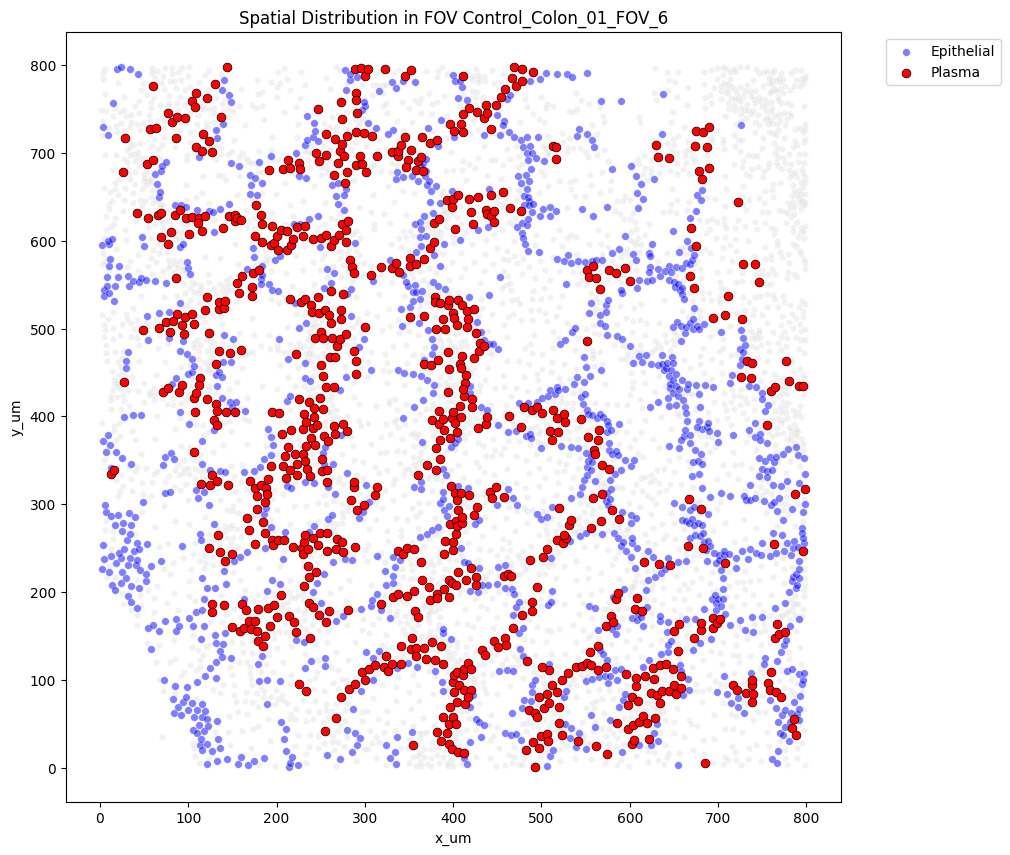

In [5]:
metrics = evaluate_cohort("Colon - Control", colon_control_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Colon - Mild

FOV: GVHD_13_FOV_1 | Transactions: 1462
  [Binary]   Sup: 0.0157 | Conf: 1.0000 | Lift: 1.0951 | PASS: False
  [Weighted] Sup: 0.0144 | Conf: 0.9183 | Lift: 1.0514 | PASS: False

FOV: GVHD_13_FOV_2 | Transactions: 1661
  [Binary]   Sup: 0.0193 | Conf: 0.9697 | Lift: 1.0358 | PASS: False
  [Weighted] Sup: 0.0180 | Conf: 0.9081 | Lift: 1.0073 | PASS: False

FOV: GVHD_13_FOV_3 | Transactions: 1294
  [Binary]   Sup: 0.0015 | Conf: 1.0000 | Lift: 1.1041 | PASS: False
  [Weighted] Sup: 0.0015 | Conf: 1.0000 | Lift: 1.1566 | PASS: False

FOV: GVHD_17_FOV_1 | Transactions: 1503
  [Binary]   Sup: 0.0067 | Conf: 0.9091 | Lift: 1.1463 | PASS: False
  [Weighted] Sup: 0.0059 | Conf: 0.8119 | Lift: 1.0952 | PASS: False

FOV: GVHD_17_FOV_2 | Transactions: 1188
  [Binary]   Sup: 0.0093 | Conf: 0.8462 | Lift: 1.3004 | PASS: False
  [Weighted] Sup: 0.0066 | Conf: 0.6045 | Lift: 1.0525 | PASS: False

FOV: GVHD_17_FOV_3 | Transactions: 1492
  [Binary]   Sup: 0.0060 | Conf:

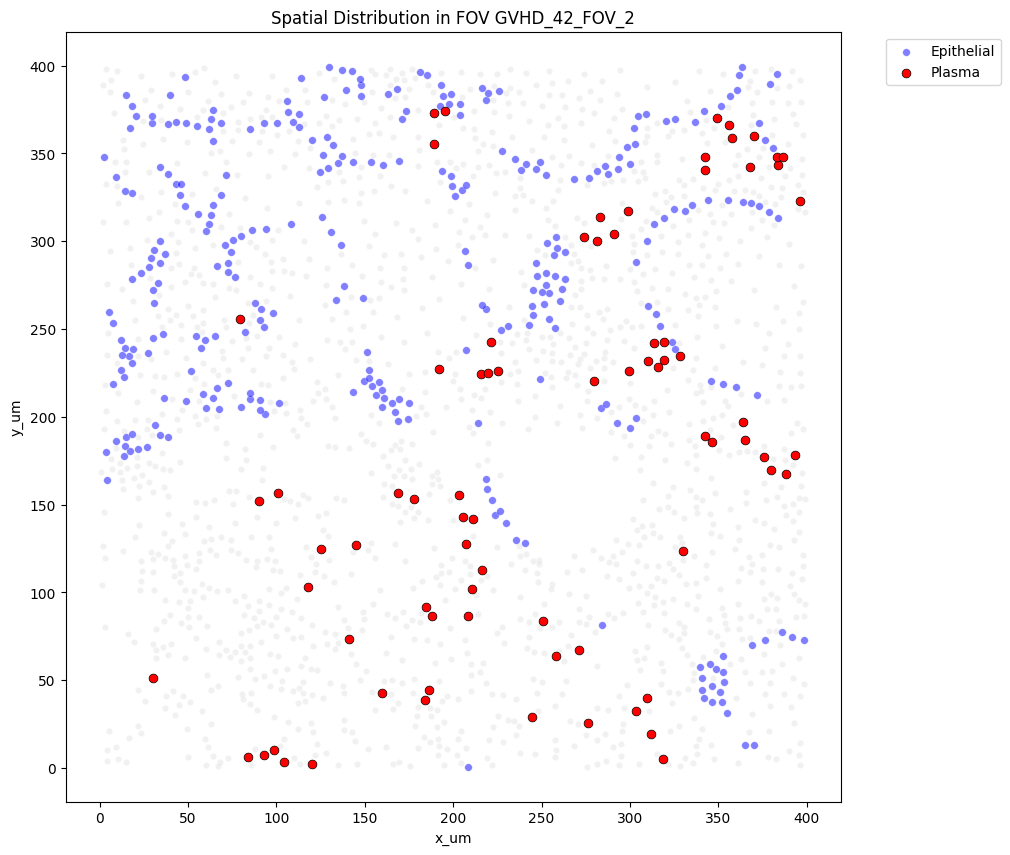

In [6]:
metrics = evaluate_cohort("Colon - Mild", colon_mild_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Colon - Severe

FOV: GVHD_01_FOV_1 | Transactions: 1801
  [Binary]   Sup: 0.0155 | Conf: 0.7778 | Lift: 0.8711 | PASS: False
  [Weighted] Sup: 0.0141 | Conf: 0.7043 | Lift: 0.8192 | PASS: False

FOV: GVHD_01_FOV_2_R | Transactions: 2040
  [Binary]   Sup: 0.0196 | Conf: 0.4167 | Lift: 0.6615 | PASS: False
  [Weighted] Sup: 0.0157 | Conf: 0.3340 | Lift: 0.5820 | PASS: False

FOV: GVHD_01_FOV_3_R | Transactions: 1852
  [Binary]   Sup: 0.0119 | Conf: 0.5366 | Lift: 0.7013 | PASS: False
  [Weighted] Sup: 0.0106 | Conf: 0.4810 | Lift: 0.6735 | PASS: False

FOV: GVHD_01_FOV_4 | Transactions: 1937
  [Binary]   Sup: 0.0325 | Conf: 0.8873 | Lift: 0.9191 | PASS: False
  [Weighted] Sup: 0.0295 | Conf: 0.8050 | Lift: 0.8622 | PASS: False

FOV: GVHD_01_FOV_5 | Transactions: 2103
  [Binary]   Sup: 0.0048 | Conf: 0.3704 | Lift: 0.4631 | PASS: False
  [Weighted] Sup: 0.0034 | Conf: 0.2657 | Lift: 0.3496 | PASS: False

FOV: GVHD_01_FOV_6_R | Transactions: 2010
  [Binary]   Sup: 0.0662

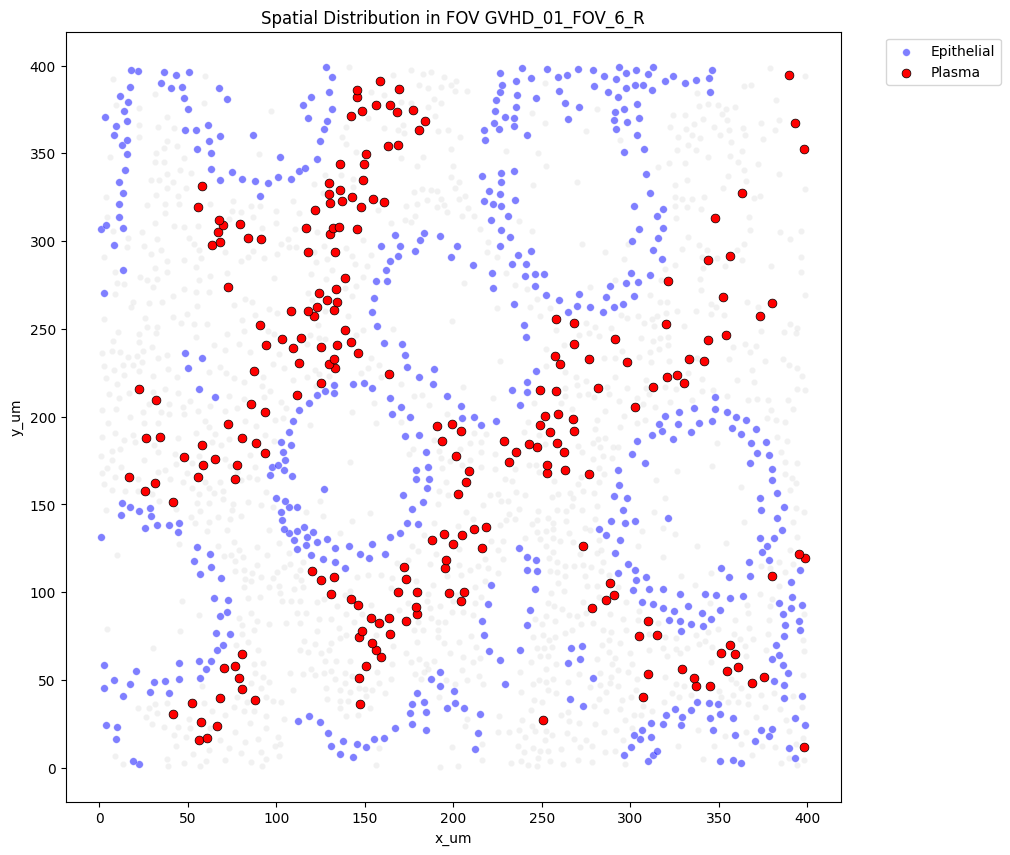

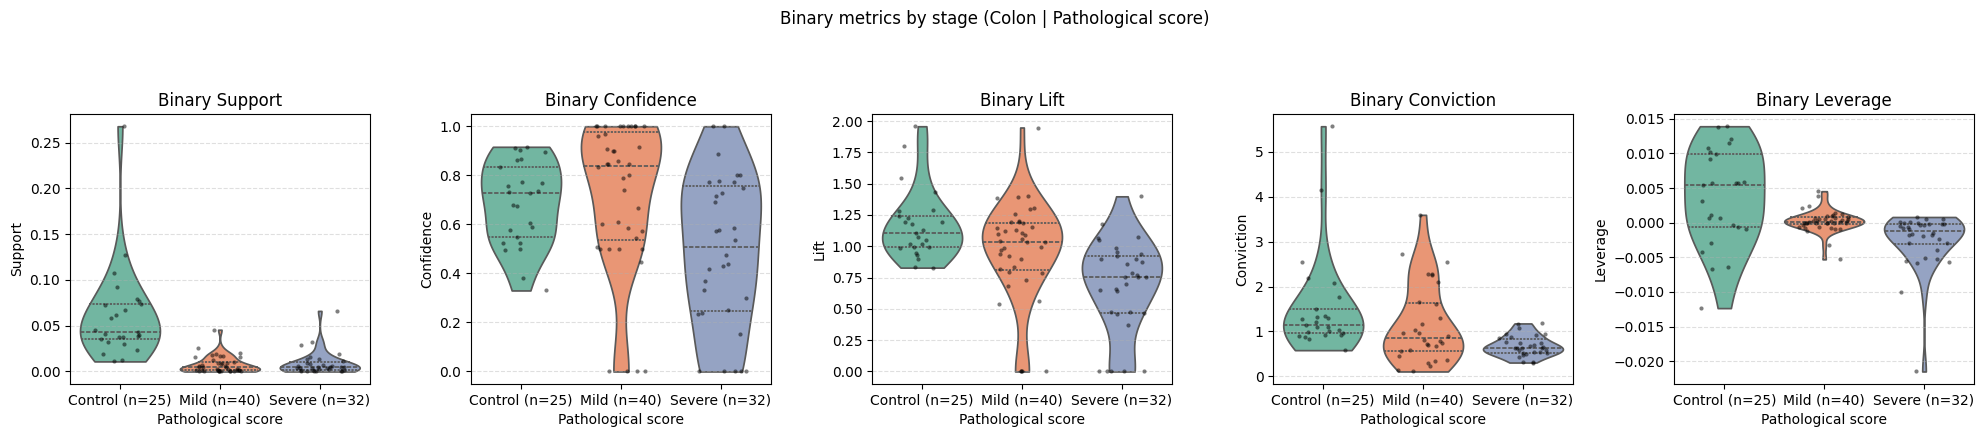

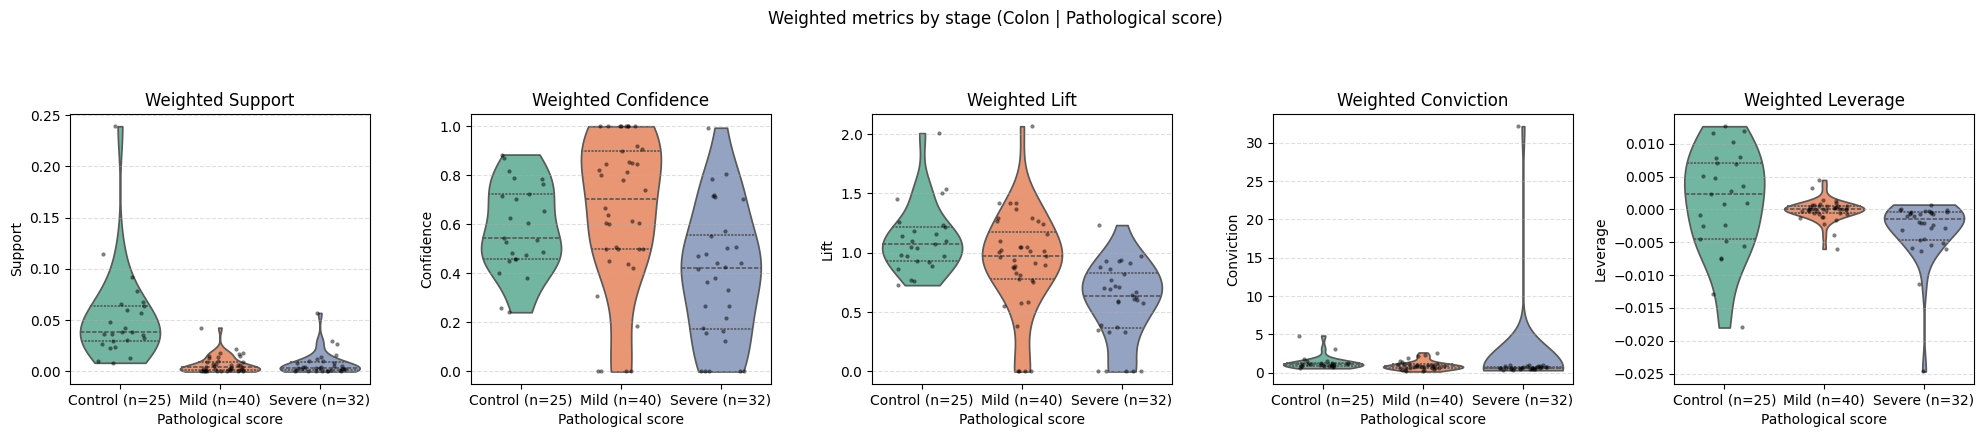

In [7]:
metrics = evaluate_cohort("Colon - Severe", colon_severe_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)
plot_stage_metric_distributions(STAGE_FOV_METRICS, organ="Colon", stage_column=STAGE_COLUMN)


Evaluating Cohort: Duodenum - Control

FOV: Control_01_FOV_1 | Transactions: 2618
  [Binary]   Sup: 0.0252 | Conf: 0.6286 | Lift: 1.3346 | PASS: True
  [Weighted] Sup: 0.0231 | Conf: 0.5750 | Lift: 1.3481 | PASS: True

FOV: Control_01_FOV_2 | Transactions: 2354
  [Binary]   Sup: 0.1109 | Conf: 0.8031 | Lift: 1.0497 | PASS: False
  [Weighted] Sup: 0.0982 | Conf: 0.7115 | Lift: 0.9992 | PASS: False

FOV: Control_01_FOV_3 | Transactions: 2157
  [Binary]   Sup: 0.0732 | Conf: 0.8634 | Lift: 1.1742 | PASS: False
  [Weighted] Sup: 0.0689 | Conf: 0.8122 | Lift: 1.1396 | PASS: False

FOV: Control_01_FOV_4 | Transactions: 2140
  [Binary]   Sup: 0.0780 | Conf: 0.8743 | Lift: 0.9393 | PASS: False
  [Weighted] Sup: 0.0729 | Conf: 0.8171 | Lift: 0.9042 | PASS: False

FOV: Control_02_FOV_1 | Transactions: 2305
  [Binary]   Sup: 0.0469 | Conf: 0.5510 | Lift: 0.7583 | PASS: False
  [Weighted] Sup: 0.0415 | Conf: 0.4881 | Lift: 0.7105 | PASS: False

FOV: Control_02_FOV_2 | Transactions: 2048
  [Binary]

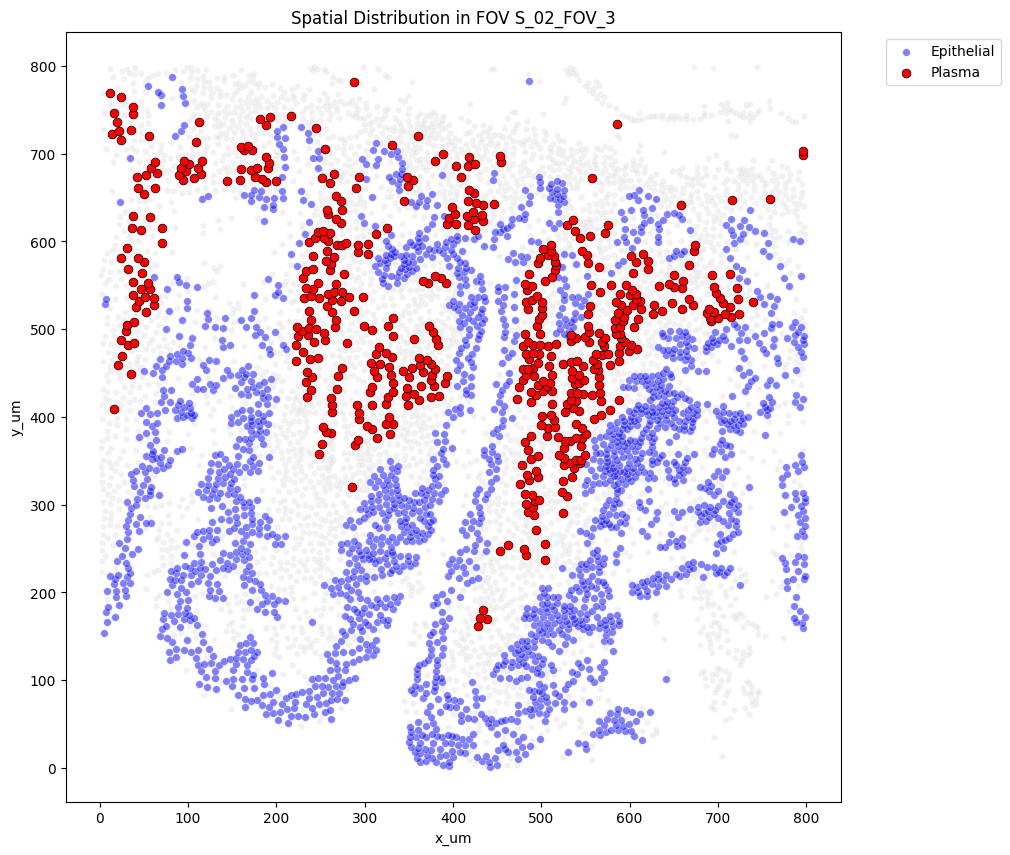

In [8]:
metrics = evaluate_cohort("Duodenum - Control", duodenum_control_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Duodenum - Mild

FOV: GVHD_03_FOV_1_R | Transactions: 2879
  [Binary]   Sup: 0.0139 | Conf: 0.6061 | Lift: 0.9619 | PASS: False
  [Weighted] Sup: 0.0123 | Conf: 0.5352 | Lift: 0.9049 | PASS: False

FOV: GVHD_03_FOV_2 | Transactions: 2524
  [Binary]   Sup: 0.0079 | Conf: 0.6667 | Lift: 1.1377 | PASS: False
  [Weighted] Sup: 0.0070 | Conf: 0.5849 | Lift: 1.0589 | PASS: False

FOV: GVHD_03_FOV_3_R | Transactions: 2615
  [Binary]   Sup: 0.0046 | Conf: 0.8571 | Lift: 1.1453 | PASS: False
  [Weighted] Sup: 0.0037 | Conf: 0.6919 | Lift: 0.9914 | PASS: False

FOV: GVHD_03_FOV_4 | Transactions: 2443
  [Binary]   Sup: 0.0033 | Conf: 0.6667 | Lift: 0.8910 | PASS: False
  [Weighted] Sup: 0.0033 | Conf: 0.6667 | Lift: 0.9354 | PASS: False

FOV: GVHD_04_FOV_1 | Transactions: 2177
  [Binary]   Sup: 0.0078 | Conf: 0.9444 | Lift: 1.5096 | PASS: False
  [Weighted] Sup: 0.0075 | Conf: 0.9085 | Lift: 1.4994 | PASS: True

FOV: GVHD_04_FOV_2 | Transactions: 2031
  [Binary]   Sup: 0.0054 |

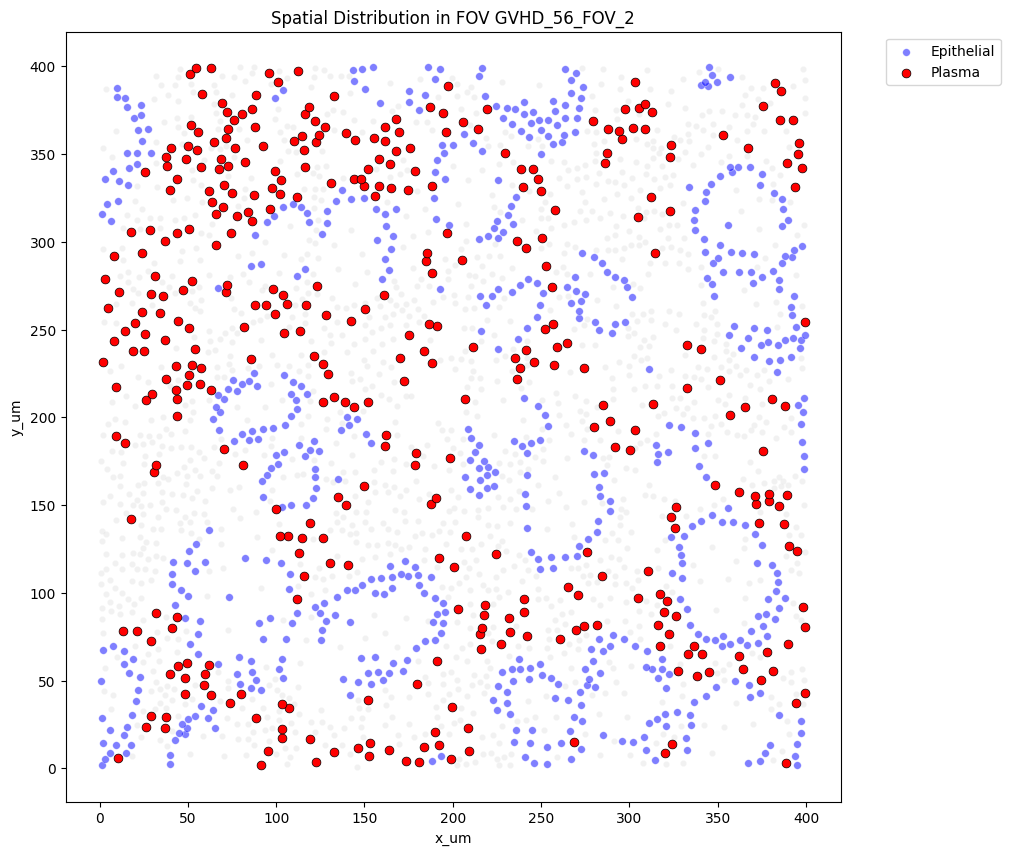

In [9]:
metrics = evaluate_cohort("Duodenum - Mild", duodenum_mild_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Duodenum - Severe

FOV: GVHD_02_FOV_1_R | Transactions: 1977
  [Binary]   Sup: 0.0172 | Conf: 0.3238 | Lift: 0.5994 | PASS: False
  [Weighted] Sup: 0.0157 | Conf: 0.2964 | Lift: 0.6322 | PASS: False

FOV: GVHD_02_FOV_2_R | Transactions: 1722
  [Binary]   Sup: 0.0145 | Conf: 0.3247 | Lift: 0.8115 | PASS: False
  [Weighted] Sup: 0.0118 | Conf: 0.2648 | Lift: 0.8232 | PASS: False

FOV: GVHD_06_FOV_1 | Transactions: 2174
  [Binary]   Sup: 0.0014 | Conf: 0.0361 | Lift: 0.1644 | PASS: False
  [Weighted] Sup: 0.0005 | Conf: 0.0132 | Lift: 0.0928 | PASS: False

FOV: GVHD_06_FOV_2 | Transactions: 2265
  [Binary]   Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Weighted] Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_06_FOV_3 | Transactions: 1998
  [Binary]   Sup: 0.0030 | Conf: 0.0811 | Lift: 0.4402 | PASS: False
  [Weighted] Sup: 0.0017 | Conf: 0.0469 | Lift: 0.3466 | PASS: False

FOV: GVHD_06_FOV_4 | Transactions: 2040
  [Binary]   Sup: 0.002

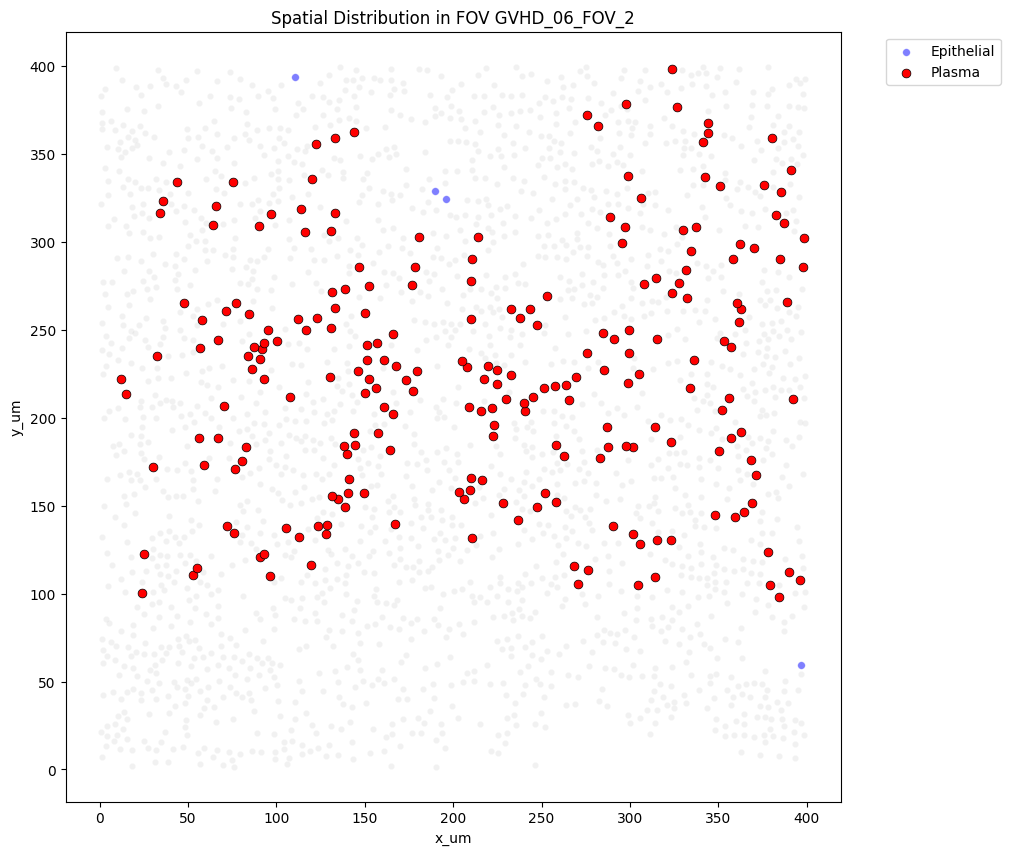

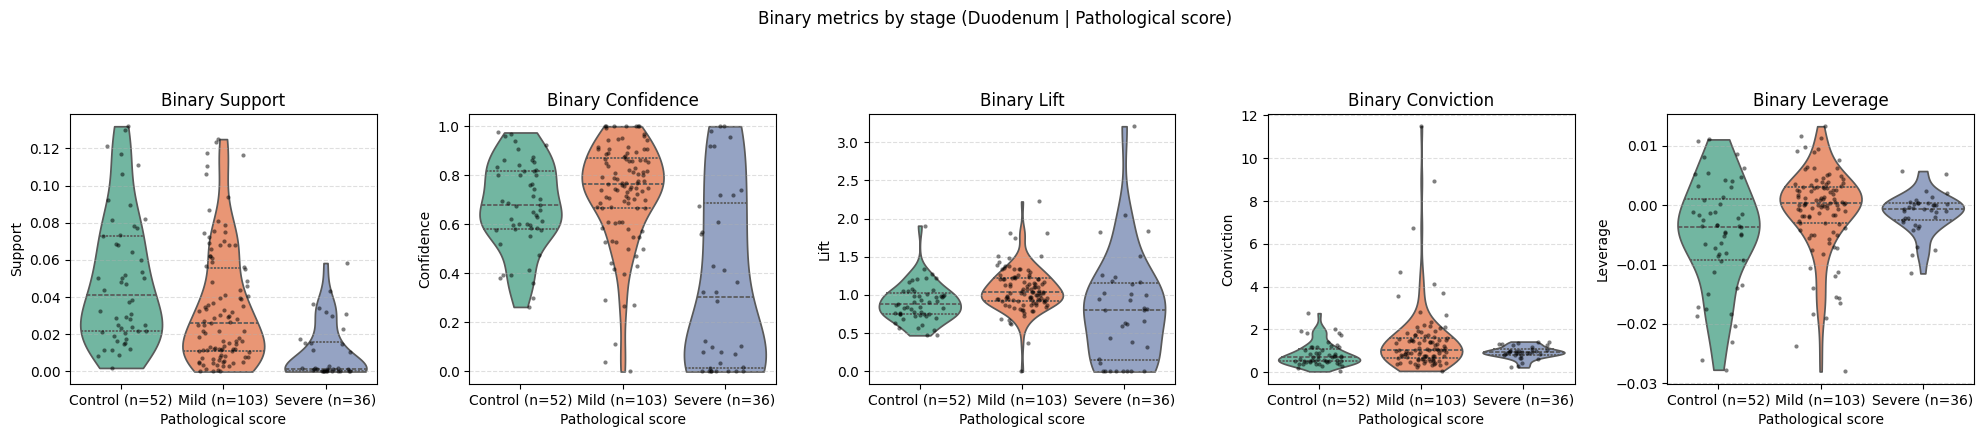

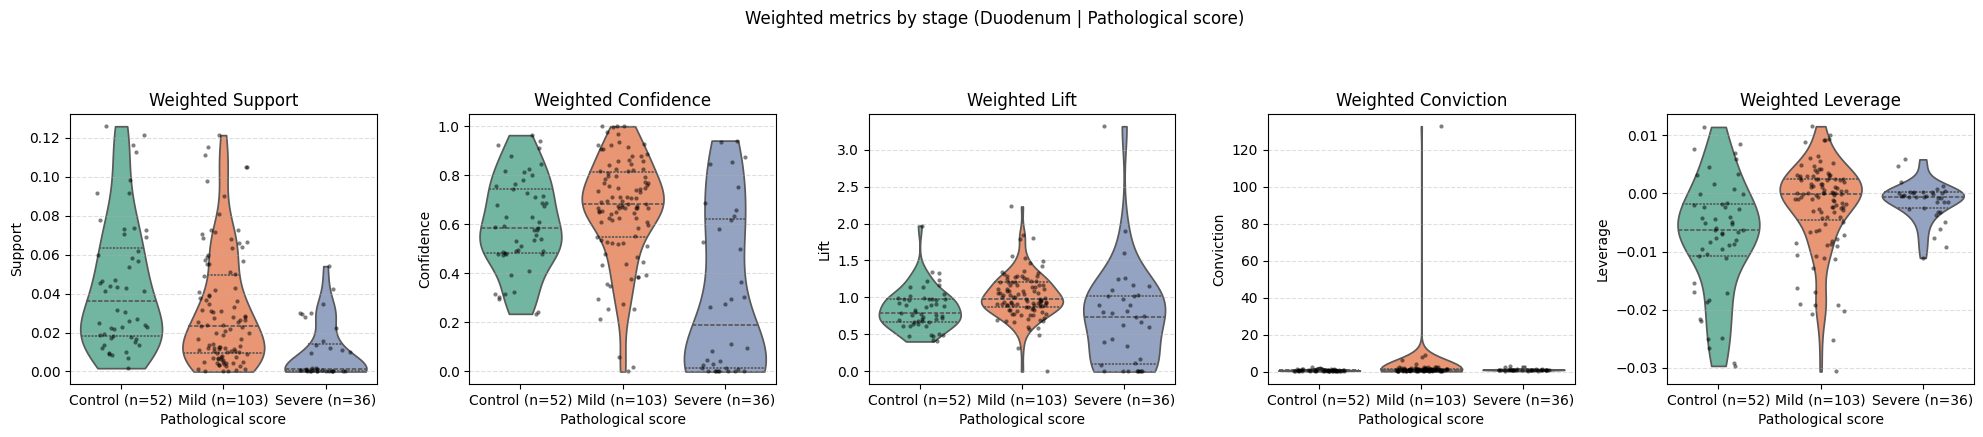

In [10]:
metrics = evaluate_cohort("Duodenum - Severe", duodenum_severe_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)
plot_stage_metric_distributions(STAGE_FOV_METRICS, organ="Duodenum", stage_column=STAGE_COLUMN)


## Spatial Visualization of FOVs
We'll now examine the spatial distribution of cells for different stages of a chosen organ. We will look at both the "representative" FOVs (the ones with the most target Antecedent cells) and randomly selected FOVs for comparison.

In [11]:
from matplotlib.ticker import MultipleLocator

# Setup color map for all cell types
all_types = sorted(df_cells["cell type"].dropna().astype(str).unique())
palette = plt.cm.get_cmap("tab20b", max(len(all_types), 1))
cell_color_map = {ct: palette(i) for i, ct in enumerate(all_types)}
OTHER_COLOR = (0.5, 0.5, 0.5) # Darker grey for non-target cells

def add_scale_bar_50um(ax, x_max, y_max):
    # Data is already in um, so 50um is just 50 units.
    bar_um = 50.0
    x_end = x_max - 25
    x_start = x_end - bar_um
    y_line = y_max - 25
    ax.plot([x_start, x_end], [y_line, y_line], color="black", linewidth=4, solid_capstyle="butt")
    ax.text((x_start + x_end) / 2, y_line - 12, "50 µm", color="black", ha="center", va="bottom", fontsize=10)

def plot_full_fov_on_ax(ax, fov_id, title, df_cells_all, target_types=None):
    df_fov = df_cells_all[df_cells_all['fov'] == fov_id].copy()
    if df_fov.empty:
        ax.text(0.5, 0.5, f"No cells for {fov_id}", ha="center", va="center")
        ax.set_axis_off()
        return

    if target_types is None:
        target_types = [ANTECEDENT_BASE, CONSEQUENT_BASE]

    ax.set_facecolor("#f2f2f2")
    
    # Plot 'Other' cells first (background)
    other_mask = ~df_fov['cell type'].isin(target_types)
    if other_mask.any():
        g = df_fov[other_mask]
        ax.scatter(g["x_um"], g["y_um"], s=10, c=[OTHER_COLOR], alpha=0.3, linewidths=0, label='Other')
        
    # Plot target cells grouped by type on top
    target_mask = df_fov['cell type'].isin(target_types)
    if target_mask.any():
        for ct, g in df_fov[target_mask].groupby("cell type"):
            color = cell_color_map.get(ct, (0, 0, 0))
            # Plot halo
            ax.scatter(g["x_um"], g["y_um"], s=40, c=[color], alpha=0.2, linewidths=0)
            # Plot center
            ax.scatter(g["x_um"], g["y_um"], s=20, c=[color], label=ct, alpha=0.9, linewidths=0)

    x_max = df_fov["x_um"].max()
    y_max = df_fov["y_um"].max()
    
    grid_spacing = 50.0 # 50 um grid
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MultipleLocator(grid_spacing))
    ax.yaxis.set_major_locator(MultipleLocator(grid_spacing))
    ax.grid(which="major", color="darkgray", linestyle="-", linewidth=0.8, alpha=0.6)
    
    add_scale_bar_50um(ax, x_max=x_max, y_max=y_max)

    ax.set_title(title, color="black", fontsize=10)
    ax.set_xlabel("x (µm)", color="black")
    ax.set_ylabel("y (µm)", color="black")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.tick_params(axis="both", colors="black", labelsize=7)
    for spine in ax.spines.values():
        spine.set_visible(False)


In [12]:
import random

ORGAN_TO_VISUALIZE = 'Duodenum' # Change to 'Duodenum' as needed

def get_max_target_fov(fov_list):
    max_count = -1
    best_fov = None
    for fov in fov_list:
        # Count target antecedent cells
        count = sum(df_cells[df_cells['fov'] == fov]['cell type'] == ANTECEDENT_BASE)
        if count > max_count:
            max_count = count
            best_fov = fov
    return best_fov, max_count

def get_random_fov(fov_list, exclude_fov):
    valid_fovs = [f for f in fov_list if f != exclude_fov]
    return random.choice(valid_fovs) if valid_fovs else exclude_fov

if ORGAN_TO_VISUALIZE == 'Colon':
    lists = [colon_control_fovs, colon_mild_fovs, colon_severe_fovs]
else:
    lists = [duodenum_control_fovs, duodenum_mild_fovs, duodenum_severe_fovs]

stages = ['Control', 'Mild', 'Severe']
rep_fovs = {}
rand_fovs = {}

for stage, flist in zip(stages, lists):
    best_fov, _ = get_max_target_fov(flist)
    rep_fovs[stage] = best_fov
    rand_fovs[stage] = get_random_fov(flist, best_fov)

print("Representative FOVs:")
for stage, fov in rep_fovs.items(): print(f"  {stage}: {fov}")
print("\nRandom FOVs:")
for stage, fov in rand_fovs.items(): print(f"  {stage}: {fov}")


Representative FOVs:
  Control: S_02_FOV_3
  Mild: GVHD_56_FOV_2
  Severe: GVHD_06_FOV_2

Random FOVs:
  Control: S_01_FOV_1
  Mild: GVHD_51_FOV_4
  Severe: GVHD_14_FOV_4


In [13]:
def plot_stage_fovs_side_by_side(organ, fov_dict, title_prefix, target_types=None):
    if target_types is None:
        target_types = [ANTECEDENT_BASE, CONSEQUENT_BASE]
        
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="white")
    
    stages = ['Control', 'Mild', 'Severe']
    
    for i, stage in enumerate(stages):
        ax = axes[i]
        fov = fov_dict[stage]
        if fov is None:
            ax.text(0.5, 0.5, f"No FOV\n{stage}", ha="center", va="center")
            ax.set_axis_off()
            continue
            
        plot_title = f"{stage} ({fov})"
        plot_full_fov_on_ax(ax, fov, plot_title, df_cells, target_types=target_types)
        
    fig.suptitle(f"{title_prefix} FOVs by Stage | {organ}", fontsize=16, y=1.02)
    
    # Shared Legend (only for targets + Other)
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=OTHER_COLOR, 
                   markeredgecolor="none", markersize=7, label="Other")
    ]
    for ct in target_types:
        handles.append(
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cell_color_map[ct], 
                       markeredgecolor="none", markersize=7, label=ct)
        )
        
    fig.legend(handles=handles, title="Cell type", loc="center left", bbox_to_anchor=(0.92, 0.5), fontsize=9, title_fontsize=10, frameon=True)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


In [14]:
import random

ORGAN_TO_VISUALIZE = 'Duodenum' # Change to 'Duodenum' as needed

def get_max_target_fov(fov_list):
    max_count = -1
    best_fov = None
    for fov in fov_list:
        # Count target antecedent cells
        count = sum(df_cells[df_cells['fov'] == fov]['cell type'] == ANTECEDENT_BASE)
        if count > max_count:
            max_count = count
            best_fov = fov
    return best_fov, max_count

def get_random_fov(fov_list, exclude_fov):
    valid_fovs = [f for f in fov_list if f != exclude_fov]
    return random.choice(valid_fovs) if valid_fovs else exclude_fov

if ORGAN_TO_VISUALIZE == 'Colon':
    lists = [colon_control_fovs, colon_mild_fovs, colon_severe_fovs]
else:
    lists = [duodenum_control_fovs, duodenum_mild_fovs, duodenum_severe_fovs]

stages = ['Control', 'Mild', 'Severe']
rep_fovs = {}
rand_fovs = {}

for stage, flist in zip(stages, lists):
    # Filter out 'S_' FOVs for Control stage to avoid structurally distinct controls
    if stage == 'Control':
        flist = [f for f in flist if not str(f).startswith('S_')]

    best_fov, _ = get_max_target_fov(flist)
    rep_fovs[stage] = best_fov
    rand_fovs[stage] = get_random_fov(flist, best_fov)

print("Representative FOVs:")
for stage, fov in rep_fovs.items(): print(f"  {stage}: {fov}")
print("\nRandom FOVs:")
for stage, fov in rand_fovs.items(): print(f"  {stage}: {fov}")


Representative FOVs:
  Control: Control_01_FOV_2
  Mild: GVHD_56_FOV_2
  Severe: GVHD_06_FOV_2

Random FOVs:
  Control: Control_02_FOV_4
  Mild: GVHD_55_FOV_1
  Severe: GVHD_57_FOV_2


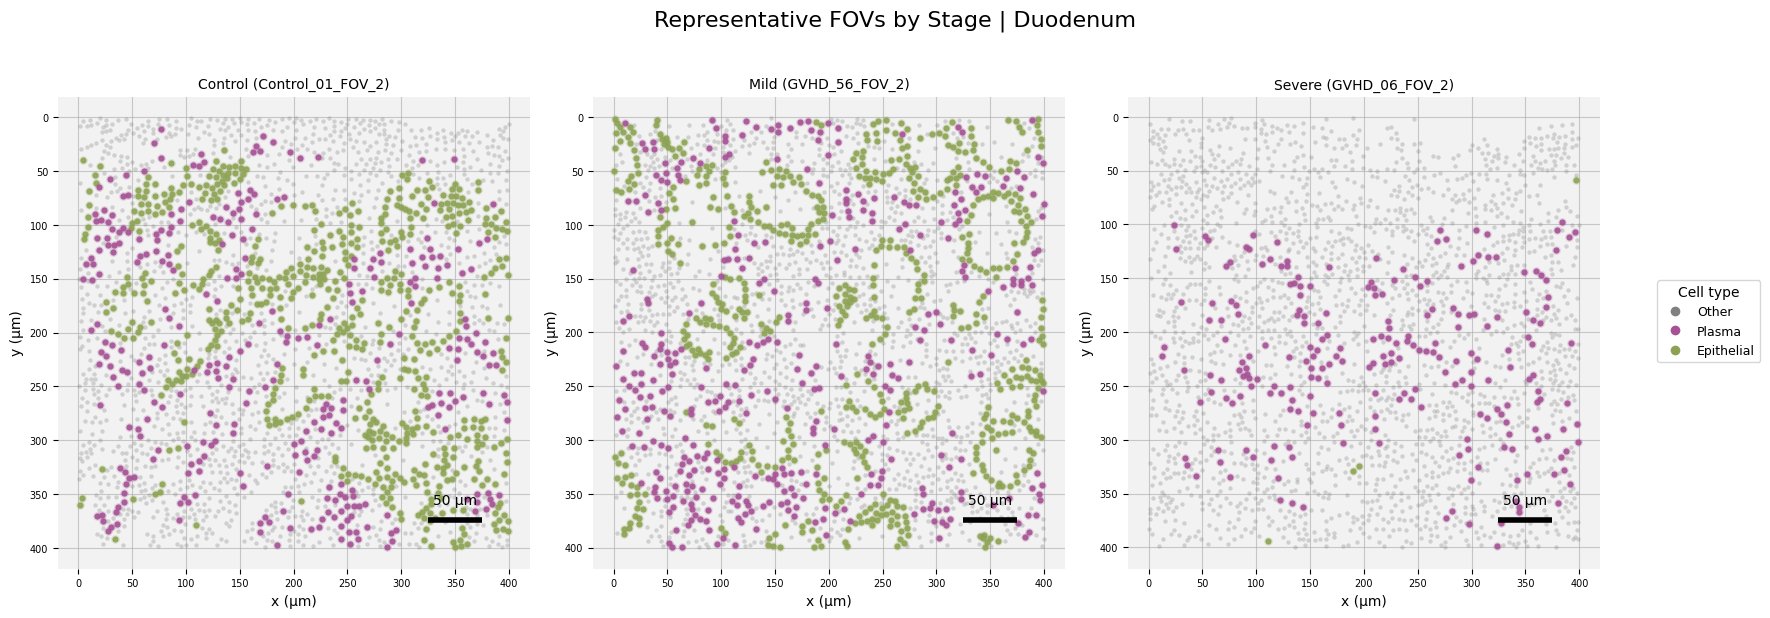

In [15]:
plot_stage_fovs_side_by_side(ORGAN_TO_VISUALIZE, rep_fovs, "Representative")

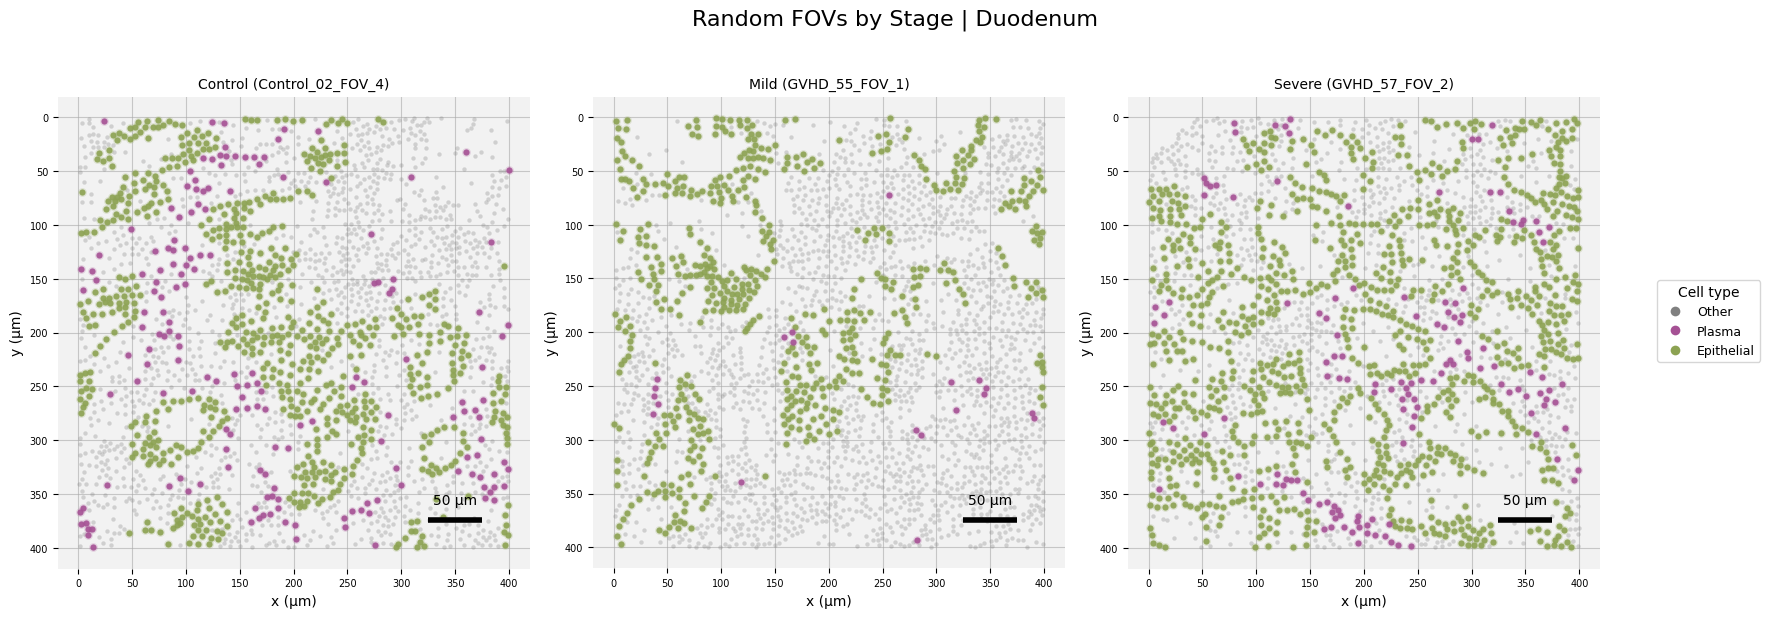

In [16]:
plot_stage_fovs_side_by_side(ORGAN_TO_VISUALIZE, rand_fovs, "Random")